In [37]:
import cv2 as cv
import xml.etree.ElementTree as ET
import os
import matplotlib.pyplot as plt

In [38]:
img_folder = 'Images'

In [39]:
annotation_folder = 'Annotation'

In [52]:
def visualization(img_filename):
    image_path = os.path.join(img_folder, img_filename)
    xml_filename = img_filename.replace('.jpg', '.xml')
    xml_path = os.path.join(annotation_folder, xml_filename)
    img = cv.imread(image_path)
    if img is None:
        print(f"Could not read image {image_path}")
        return
    tree = ET.parse(xml_path)
    root = tree.getroot() # Gets the root element of the XML tree to start navigating through the XML nodes
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        cv.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        cv.putText(img, label, (xmin, ymin-10), cv.FONT_HERSHEY_SIMPLEX, 0.6, (36, 255, 12), 2)
        plt.imshow(img)

    

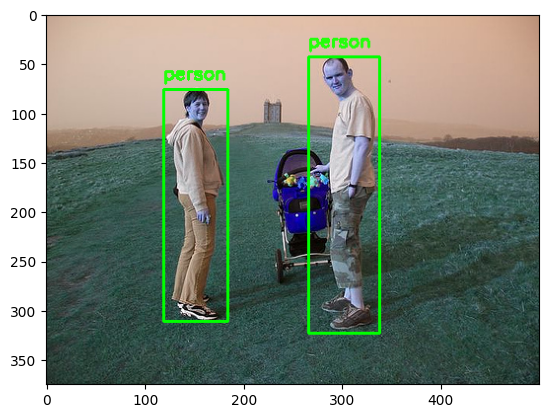

In [53]:
visualization('2008_000200.jpg')